## ROS2 validation: current step tests

**Goal**: validate the offline simulation results against the full
ROS2 node-based architecture, by comparing them on the same current profile instead of re-running a full magnitude sweep in ROS2.

**Scope**: surge axis only (0°). It is the task-critical axis
(70–150 cm detection window), and the offline sweep showed 0° and
180° behave symmetrically for both controllers, so one direction is
enough to validate the phenomenon.

**Why a step sequence, not a continuous ramp**: a continuous ramp
(current rising linearly over time) would not give a true
steady-state error, since near the PID's failure threshold the
settling time is itself ~50–60s. Instead, we test
a sequence of fixed current values one after another, each held long enough for the vehicle to reach true steady state before moving to the next value — so each segment is
equivalent to a separate offline run, all captured in a single continuous bag.

**Setup**:
- `marine_current_node`: a sequence of magnitudes (e.g.
  `[0.3, 0.7, 0.85, 0.9, 1.0, 1.2]`), `current_direction_deg:=0.0`,
  each value held for a fixed duration (e.g. 70 s) before switching
  to the next
- Run once with the PID controller node, once with the SMC controller
  node, same sequence, same `x_ref`
- Log `/bluerov2/odom` (position `x`, hence $e_x = x_{ref} - x$) and
  `/bluerov2/tau_cmd` (thrust $\tau_u$) throughout each run, for both
  controllers, then convert the bag to CSV
- Reproduce the same sequence in `offline_sim.py` with the same
  `x_ref` and values, to get the offline reference curve

**Metrics**:
- **PID**: position error $e_x$ at the end of each segment, to locate
  the failure threshold
- **SMC**: both $\tau_u$ (to see when saturation kicks in) and $e_x$
  (to see whether the vehicle stays bounded near the target once
  saturated) — the interesting result is the relationship between the
  two, not either alone


In [5]:
import pandas as pd

df_pid = pd.read_csv('bag_pid_v3.csv')
df_smc = pd.read_csv('bag_smc_v3.csv')

print("PID -> righe:", len(df_pid), " t max:", df_pid['t'].max())
print("SMC -> righe:", len(df_smc), " t max:", df_smc['t'].max())

# controllo veloce sui buchi temporali (come prima)
print("\nMax gap PID:", df_pid['t'].diff().max())
print("Max gap SMC:", df_smc['t'].diff().max())

# controllo che la corrente sia stata registrata davvero
print("\nValori unici di current_x (PID):", sorted(df_pid['current_x'].unique()))
print("Valori unici di current_x (SMC):", sorted(df_smc['current_x'].unique()))

PID -> righe: 48858  t max: 488.5997622013092
SMC -> righe: 48949  t max: 489.6496391296387

Max gap PID: 0.018363237380953024
Max gap SMC: 0.024634122848510742

Valori unici di current_x (PID): [0.0, 0.3, 0.7, 0.85, 0.9, 1.0, 1.2]
Valori unici di current_x (SMC): [0.0, 0.3, 0.7, 0.85, 0.9, 1.0, 1.2]


In [6]:
x_ref = 0.9

df_pid['e_x'] = x_ref - df_pid['x']
df_smc['e_x'] = x_ref - df_smc['x']

def extract_step_averages_from_current(df, step_values, avg_last_seconds=10.0, value_col='e_x'):
    """
    Usa la colonna current_x (registrata nel bag) per identificare
    davvero a quale gradino appartiene ogni riga, invece di fidarsi
    del tempo teorico. Poi media 'value_col' sugli ultimi
    avg_last_seconds secondi di ciascun gradino.
    """
    mags, values = [], []
    for mag in step_values:
        segment_df = df[np.isclose(df['current_x'], mag, atol=1e-6)]
        if len(segment_df) == 0:
            print(f"ATTENZIONE: nessuna riga trovata per corrente={mag}")
            continue

        t_end = segment_df['t'].max()
        window_start = t_end - avg_last_seconds
        tail = segment_df[segment_df['t'] >= window_start][value_col]

        mags.append(mag)
        values.append(tail.mean())

    return np.array(mags), np.array(values)


step_values = [0.3, 0.7, 0.85, 0.9, 1.0, 1.2]

mags_pid, ex_pid = extract_step_averages_from_current(df_pid, step_values, value_col='e_x')
_,        tau_pid = extract_step_averages_from_current(df_pid, step_values, value_col='tau_u')

mags_smc, ex_smc = extract_step_averages_from_current(df_smc, step_values, value_col='e_x')
_,        tau_smc = extract_step_averages_from_current(df_smc, step_values, value_col='tau_u')

print("PID -> mag:", mags_pid, " e_x:", np.round(ex_pid, 3), " tau_u:", np.round(tau_pid, 2))
print("SMC -> mag:", mags_smc, " e_x:", np.round(ex_smc, 3), " tau_u:", np.round(tau_smc, 2))

PID -> mag: [0.3  0.7  0.85 0.9  1.   1.2 ]  e_x: [-0.     0.003 -0.042 -0.28  -0.795 -1.969]  tau_u: [ -2.85 -11.71 -16.56 -18.35 -22.21 -31.02]
SMC -> mag: [0.3  0.7  0.85 0.9  1.   1.2 ]  e_x: [-0.008 -0.032 -0.046 -0.05  -0.061 -0.085]  tau_u: [ -2.85 -11.73 -16.56 -18.35 -22.21 -31.02]


In [8]:
import sys
sys.path.append('.')  

from offline_sim import run_simulation_steps, step_end_values

x_ref = 0.9
step_values = [0.3, 0.7, 0.85, 0.9, 1.0, 1.2]
step_duration = 70.0

gains_pid = dict(
    kp_u=7.5, ki_u=0.65, kd_u=11.0,
    kp_v=9.5, ki_v=0.85, kd_v=20.0,
    kp_r=0.44, ki_r=0.055, kd_r=0.49,
    tau_max_linear=60.0, tau_max_yaw=5.0,
)
gains_smc = dict(
    lambda_u=0.5, k_u=3.55, phi_u=0.083,
    lambda_v=0.5, k_v=4.70, phi_v=0.09,
    lambda_r=1.0, k_r=2.0, phi_r=0.1,
    tau_max_linear=60.0, tau_max_yaw=5.0,
)

res_pid_offline = run_simulation_steps('pid', x_ref, 0.0, 0.0, step_values, step_duration,
                                        current_direction_deg=0.0, gains=gains_pid)
res_smc_offline = run_simulation_steps('smc', x_ref, 0.0, 0.0, step_values, step_duration,
                                        current_direction_deg=0.0, gains=gains_smc)

mags_pid_off, x_pid_off = step_end_values(res_pid_offline, step_duration, len(step_values), key='x')
_,            tau_pid_off = step_end_values(res_pid_offline, step_duration, len(step_values), key='tau_u')
mags_smc_off, x_smc_off = step_end_values(res_smc_offline, step_duration, len(step_values), key='x')
_,            tau_smc_off = step_end_values(res_smc_offline, step_duration, len(step_values), key='tau_u')

ex_pid_off = x_ref - x_pid_off
ex_smc_off = x_ref - x_smc_off

print("PID offline -> e_x:", np.round(ex_pid_off, 3), " tau_u:", np.round(tau_pid_off, 2))
print("SMC offline -> e_x:", np.round(ex_smc_off, 3), " tau_u:", np.round(tau_smc_off, 2))

PID offline -> e_x: [ 0.000e+00  1.000e-03 -4.100e-02 -2.800e-01 -7.950e-01 -1.969e+00]  tau_u: [ -2.85 -11.72 -16.56 -18.35 -22.21 -31.01]
SMC offline -> e_x: [-0.008 -0.032 -0.046 -0.05  -0.061 -0.085]  tau_u: [ -2.85 -11.73 -16.56 -18.35 -22.21 -31.02]


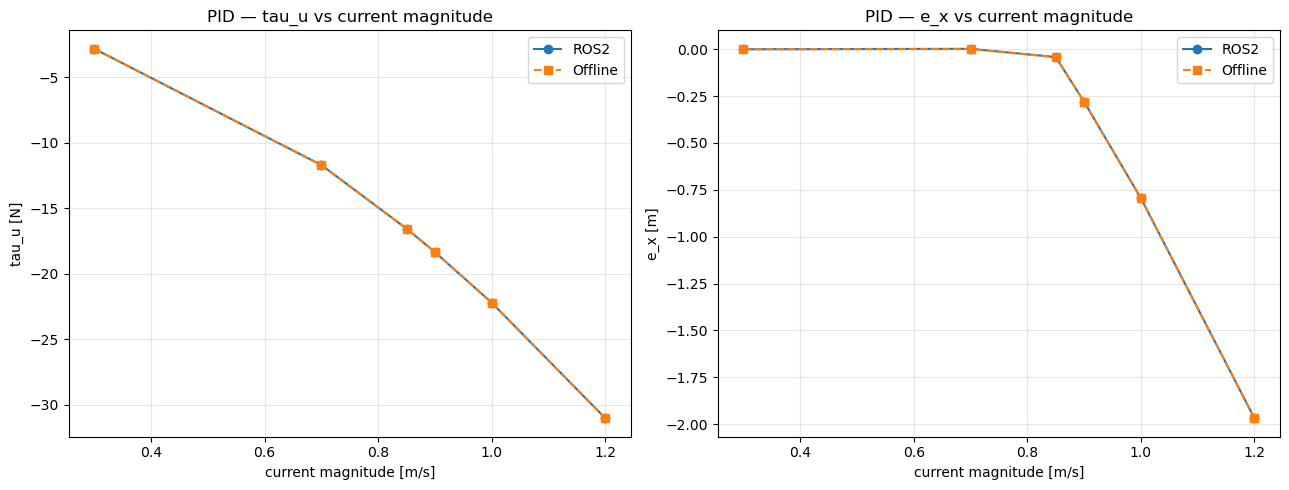

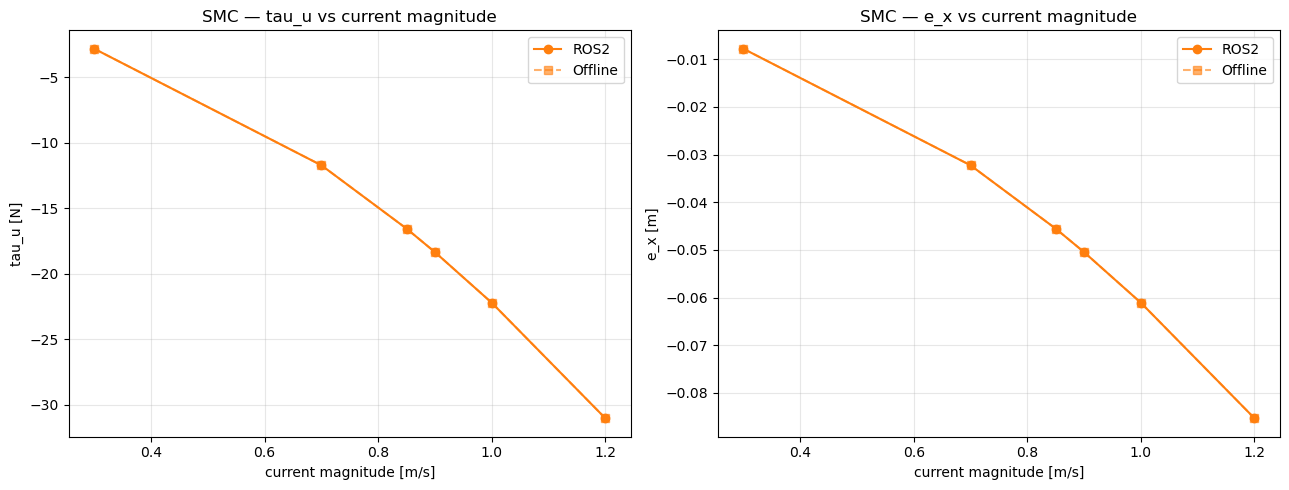

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mags_pid, tau_pid, 'o-', label='ROS2')
axes[0].plot(mags_pid_off, tau_pid_off, 's--', label='Offline')
axes[0].set_xlabel('current magnitude [m/s]')
axes[0].set_ylabel('tau_u [N]')
axes[0].set_title('PID — tau_u vs current magnitude')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mags_pid, ex_pid, 'o-', label='ROS2')
axes[1].plot(mags_pid_off, ex_pid_off, 's--', label='Offline')
axes[1].set_xlabel('current magnitude [m/s]')
axes[1].set_ylabel('e_x [m]')
axes[1].set_title('PID — e_x vs current magnitude')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ros2_vs_offline_pid.png', dpi=150, bbox_inches='tight')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(mags_smc, tau_smc, 'o-', color='tab:orange', label='ROS2')
axes[0].plot(mags_smc_off, tau_smc_off, 's--', color='tab:orange', alpha=0.6, label='Offline')
axes[0].set_xlabel('current magnitude [m/s]')
axes[0].set_ylabel('tau_u [N]')
axes[0].set_title('SMC — tau_u vs current magnitude')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mags_smc, ex_smc, 'o-', color='tab:orange', label='ROS2')
axes[1].plot(mags_smc_off, ex_smc_off, 's--', color='tab:orange', alpha=0.6, label='Offline')
axes[1].set_xlabel('current magnitude [m/s]')
axes[1].set_ylabel('e_x [m]')
axes[1].set_title('SMC — e_x vs current magnitude')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ros2_vs_offline_smc.png', dpi=150, bbox_inches='tight')
plt.show()